In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- Global Variables ---
data = pd.read_csv("./feeds.csv")
# lower = 40744
# upper = 43796
# lower2 = 26059
# upper2 = 28057
field = "field7"

# --- Utility Functions ---

def pickfield(data, field_nr):
    field = data[data[field_nr] > 10]
    return field

def plotfield(field_nr):
    field = pickfield(data, field_nr)
    ax = plt.gca()
    ax.scatter(x=field["entry_id"], y=field[field_nr])
    ax.set_yscale('log')

def select_range(data, field_nr, start, end):
    field = pickfield(data, field_nr)
    field = field[field["entry_id"] > start]
    field = field[field["entry_id"] < end]
    return field

# --- Core Calculation Function ---

def math(lower, upper):
    # --- FIXED PARAMETERS ---
    baseline_limit = lower + 864  # Entry ID for the first 3 days (864 points)
    start_id = baseline_limit     # Start analysis AFTER the baseline data
    end_id = upper                # End of chunking
    chunk_size = 36
    STOP_TOLERANCE = 0.01
    smaller = 0
    prev_diff = 0
    
    # --- 1. CALCULATE STABLE HISTORICAL BASELINE MEAN ---
    # This data is NOT included in the chunking analysis.
    baseline_data = select_range(data, field, lower, baseline_limit)
    if baseline_data.empty:
        print("Error: Baseline data not found.")
        return

    # Calculate differences over the baseline period
    baseline_diffs = baseline_data[field].diff().dropna()
    og_mean = baseline_diffs.mean()
    ABSOLUTE_STOP_THRESHOLD = og_mean + STOP_TOLERANCE
    print(f"Historical Baseline Mean (First 3 Days: {lower} to {baseline_limit}): {og_mean:.4f}")

    # --- 2. SELECT DATA FOR CHUNKING AND ANALYSIS ---
    chunking_data = select_range(data, field, start_id, end_id)
    if chunking_data.empty:
        print(f"No data found in the analysis range: {start_id} to {end_id}.")
        return

    # Calculate all differences for the analysis range
    diffs = chunking_data[field].diff().dropna()

    # --- 3. ITERATE, CHUNK, AND APPLY DECAYING TOLERANCE ---
    #print("\n--- Mean of Diffs (72 Datapoint Chunks) ---\n")

    num_diffs = len(diffs)
    current_index = 0

    while current_index < num_diffs:
        chunk = diffs.iloc[current_index:current_index + chunk_size]
        
        # Mapping for output
        start_idx = chunk.index[0]
        end_idx = chunk.index[-1]
        start_entry_id = chunking_data.loc[start_idx, "entry_id"]
        end_entry_id = chunking_data.loc[end_idx, "entry_id"]
        
        mean_diff = chunk.mean()

        # print(f"Entry IDs {start_entry_id:5} to {end_entry_id:5}: Mean Diff = {mean_diff:.4f} | Threshold = {ABSOLUTE_STOP_THRESHOLD:.4f}")
        
        # APPLY THE CHECK (STOP if mean is GREATER than the decaying threshold)
        if mean_diff >= ABSOLUTE_STOP_THRESHOLD:
            print("STOP! Current mean exceeds the fixed threshold.")
            break
        

        # if prev_diff < mean_diff and smaller == 0:
        #     smaller += 1
        # else:
        #     smaller = 0

        # if prev_diff > mean_diff:
        #     smaller += 1
        # else:
        #     smaller = 0

        prev_diff = mean_diff

        if smaller == 3:
            print("STOP! Current mean exceeds the fixed threshold.")
            break
        current_index += chunk_size
        
    return end_entry_id

# --- Execution ---


Historical Baseline Mean (First 3 Days: 22773 to 23637): -0.0310
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 24183 to 25047): -0.0311
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 26114 to 26978): -0.0356
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 28122 to 28986): -0.0297
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 30088 to 30952): -0.0287
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 32309 to 33173): -0.0336
Historical Baseline Mean (First 3 Days: 34012 to 34876): -0.0378
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 36812 to 37676): -0.0303
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First 3 Days: 38792 to 39656): -0.0275
STOP! Current mean exceeds the fixed threshold.
Historical Baseline Mean (First

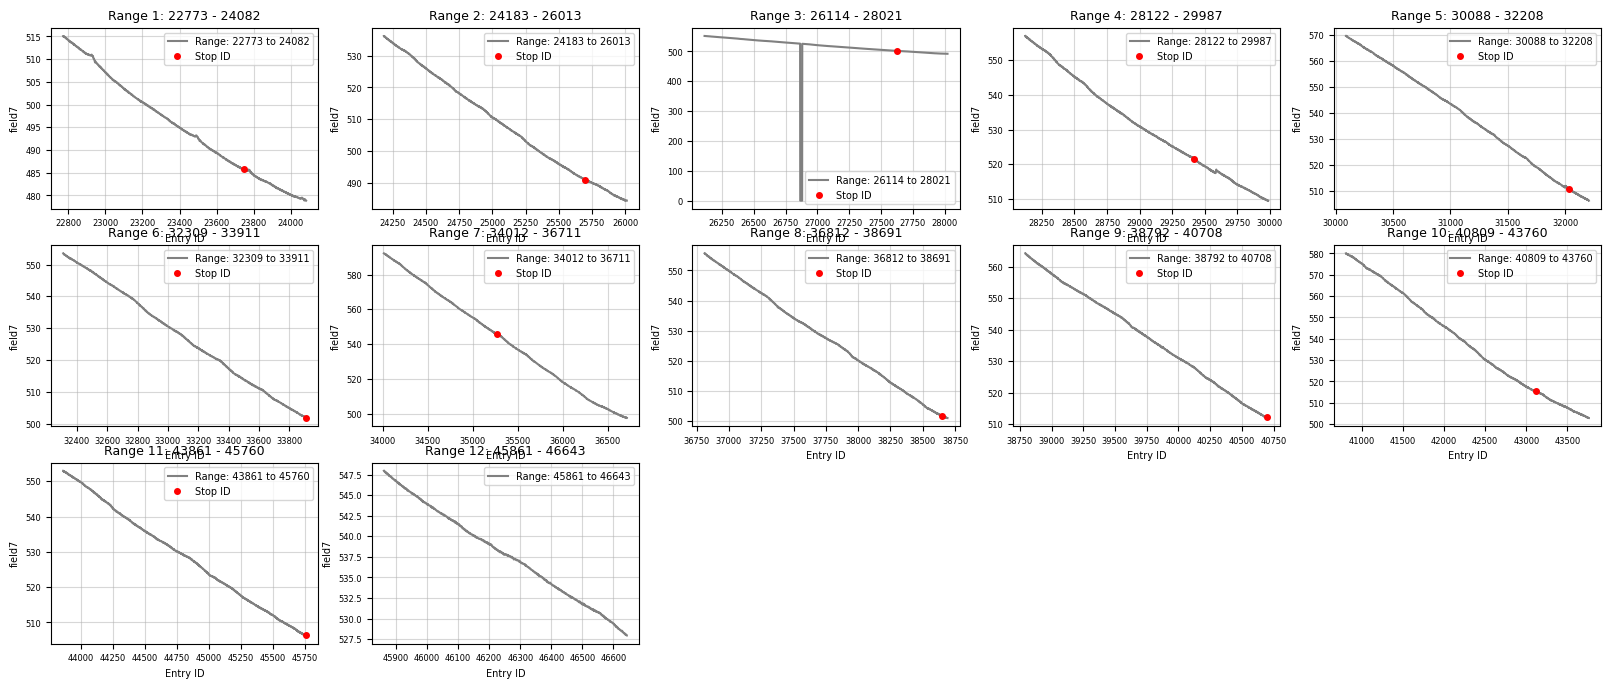

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [256]:
fields_to_test = [(np.int64(22673), np.int64(24082)), (np.int64(24083), np.int64(26013)), (np.int64(26014), np.int64(28021)), (np.int64(28022), np.int64(29987)), (np.int64(29988), np.int64(32208)), (np.int64(32209), np.int64(33911)), (np.int64(33912), np.int64(36711)), (np.int64(36712), np.int64(38691)), (np.int64(38692), np.int64(40708)), (np.int64(40709), np.int64(43760)), (np.int64(43761), np.int64(45760)), (np.int64(45761), np.int64(46643))]

N_PLOTS = len(fields_to_test)

# Define the grid: 2 Rows and 6 Columns for a wide layout
N_ROWS = 3 
N_COLS = 5

# 1. Initialize the Figure and Axes Grid
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(20, 8), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy indexing

for i, field_range in enumerate(fields_to_test):
    lower_bound = field_range[0]+100
    upper_bound = field_range[1]
    end_id = math(lower_bound, upper_bound)
    plt.figure(figsize=(12, 8)) 
    ax = axes[i]
    
    # Filter the data segment based on entry_id
    seg = data[(data['entry_id'] >= lower_bound) & (data['entry_id'] <= upper_bound)]

    if not seg.empty:
            x = seg['entry_id']
            y = seg["field7"].astype(float)
            
            ax.plot(x, y, '-', markersize=3, label=f'Range: {lower_bound} to {upper_bound}', color='gray')
            
            # Look up the stop point
            stop_data = seg[seg['entry_id'] == end_id]
    
            if not stop_data.empty:
                stop_x = stop_data['entry_id'].iloc[0]
                stop_y = stop_data["field7"].iloc[0]
            
                # Plot the red dot on the current subplot
                ax.plot(stop_x, stop_y, 'ro', markersize=4, label='Stop ID')
                
            ax.set_title(f'Range {i+1}: {lower_bound} - {upper_bound}', fontsize=9)
            ax.set_xlabel('Entry ID', fontsize=7)
            ax.set_ylabel("field7", fontsize=7)
            ax.grid(True, alpha=0.5)
            ax.legend(fontsize=7)
            ax.tick_params(axis='both', which='major', labelsize=6) # Reduce tick size for readability

# Remove any unused subplots (if you had, say, 11 plots instead of 12)
for j in range(N_PLOTS, N_ROWS * N_COLS):
    fig.delaxes(axes[j])

# Adjust subplot parameters for a tight layout
plt.tight_layout() 

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:107: SyntaxWarning: invalid escape sequence '\s'
<>:112: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:107: SyntaxWarning: invalid escape sequence '\s'
<>:112: SyntaxWarning: invalid escape sequence '\s'
C:\Users\kevinnoormets\AppData\Local\Temp\ipykernel_30296\4053714406.py:50: SyntaxWarning: invalid escape sequence '\s'
  color='green', marker='o', s=50, zorder=10, label='> 3$\sigma_e$ Outlier')
C:\Users\kevinnoormets\AppData\Local\Temp\ipykernel_30296\4053714406.py:58: SyntaxWarning: invalid escape sequence '\s'
  axs[i, 1].axhline(threshold, color='orange', linestyle='--', labe

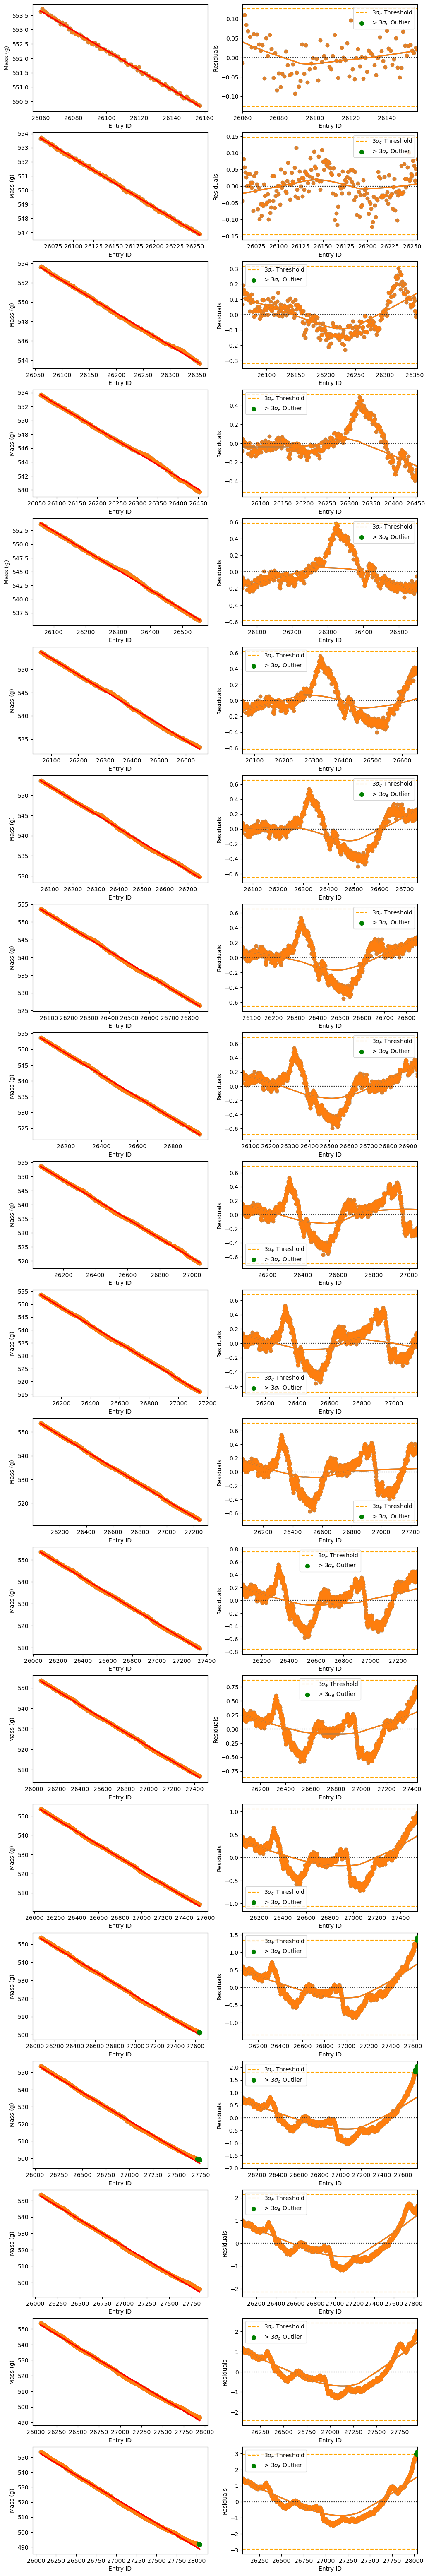

In [23]:
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.formula.api import ols 
import matplotlib.pyplot as plt

lower = 26059 #30023 40744 36747
upper = 28052 #32244 43796 38727
diff = upper-lower
chunks = 20

fig, axs = plt.subplots(chunks, 2, figsize=(12, chunks*4))
for i in range(chunks):
    chunkdiff = diff//chunks
    currentlower = lower + i*chunkdiff
    currentupper = lower + (i+1)*chunkdiff 
    field = select_range(data, "field7",lower, currentupper)
    
    # 1. Fit the OLS Model
    X = sm.add_constant(field['entry_id']) # Adds the intercept
    Y = field['field7']
    model = sm.OLS(Y, X).fit()
    
    # 2. Get the Residuals
    residuals = model.resid
    
    # 3. Calculate the Standard Deviation of the Residuals (sigma_e)
    # The 'scale' attribute of the results object is the variance (sigma_e^2)
    # The standard deviation is the square root of the scale.
    sigma_e = np.sqrt(model.scale)
    
    # 4. Identify Outliers
    threshold = 3 * sigma_e
    
    # Create a boolean mask for the outliers
    outlier_mask = np.abs(residuals) > threshold
    
    # Filter the original data and residuals to get only the outliers
    outlier_data = field[outlier_mask]
    outlier_residuals = residuals[outlier_mask]
    
    # --- Plotting ---
    
    # Plot 1: Regression Plot (as you have it)
    sns.regplot(x='entry_id', y='field7', data=field, order=1, line_kws=dict(color="r"), ax=axs[i, 0], ci=None)
    
    # Add a point for the outliers in the REGRESSION plot (axs[i, 0])
    axs[i, 0].scatter(outlier_data['entry_id'], outlier_data['field7'], 
                      color='green', marker='o', s=50, zorder=10, label='> 3$\sigma_e$ Outlier')

    
    # Plot 2: Residual Plot
    sns.residplot(x='entry_id', y='field7', data=field, order=1, ax=axs[i, 1], lowess=True)


    # Add points/lines for the outliers and the threshold lines in the RESIDUAL plot (axs[i, 1])
    axs[i, 1].axhline(threshold, color='orange', linestyle='--', label='3$\sigma_e$ Threshold')
    axs[i, 1].axhline(-threshold, color='orange', linestyle='--')
    
    # Add a point for the outliers in the RESIDUAL plot
    axs[i, 1].scatter(outlier_data['entry_id'], outlier_residuals, 
                      color='green', marker='o', zorder=10, s=50, label='> 3$\sigma_e$ Outlier')
    
    axs[i, 1].legend() # Display legend for the residual plot

    # Plot regression line and residuals
    sns.regplot(x='entry_id', y='field7', data=field, order = 1, line_kws=dict(color="r"), ax=axs[i,0], ci = None)
    axs[i,0].set_ylabel("Mass (g)")
    axs[i,0].set_xlabel("Entry ID")
    sns.residplot(x='entry_id', y='field7', data=field, order = 1, ax=axs[i, 1], lowess = True)
    axs[i,1].set_ylabel("Residuals")
    axs[i,1].set_xlabel("Entry ID")